In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image 

In [3]:
# Object points in 3D
GRID_SHAPE = (9,7)
objp = np.zeros((GRID_SHAPE[0]*GRID_SHAPE[1],3), np.float32)
objp[:,:2] = np.mgrid[0:GRID_SHAPE[0], 0:GRID_SHAPE[1]].T.reshape(-1,2)
objp *= 20 # One square on my grid has 20mm

In [4]:
folder_right = "calib_images/right/"
folder_left = "calib_images/left/"

In [5]:
# Load parameters
(K_l, K_r, dist_l, dist_r) = np.load("K_l.npy"), np.load("K_r.npy"), np.load("dist_coeff_l.npy"), np.load("dist_coeff_r.npy")

## Stereo

In [6]:
obj_pts = []
img_pts_l, img_pts_r = [], []

for fname_l, fname_r in zip(sorted(os.listdir(folder_left)), sorted(os.listdir(folder_right))):

    print(f"processing {fname_l, fname_r}")
    img_l, img_r = Image.open(folder_left + fname_l), Image.open(folder_right + fname_r)
    arr_l, arr_r = np.array(img_l), np.array(img_r)
    if arr_l.ndim == 3:
        arr_l = cv2.cvtColor(arr_l, cv2.COLOR_BGR2GRAY)
    if arr_r.ndim == 3:
        arr_r = cv2.cvtColor(arr_r, cv2.COLOR_BGR2GRAY)
    gray_l, gray_r = arr_l, arr_r

    flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_FAST_CHECK
    ret_l, corners_l = cv2.findChessboardCorners(gray_l, GRID_SHAPE, flags)
    ret_r, corners_r = cv2.findChessboardCorners(gray_r, GRID_SHAPE, flags)

    if ret_l and ret_r:
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        corners_subpix_l = cv2.cornerSubPix(gray_l, corners_l, (11,11), (-1,-1), criteria)
        corners_subpix_r = cv2.cornerSubPix(gray_r, corners_r, (11,11), (-1,-1), criteria)

        obj_pts.append(objp)
        img_pts_l.append(corners_subpix_l)
        img_pts_r.append(corners_subpix_r)

processing ('000.png', '000.png')
processing ('001.png', '001.png')
processing ('002.png', '002.png')
processing ('003.png', '003.png')
processing ('004.png', '004.png')
processing ('005.png', '005.png')
processing ('006.png', '006.png')
processing ('007.png', '007.png')
processing ('008.png', '008.png')
processing ('009.png', '009.png')
processing ('010.png', '010.png')
processing ('011.png', '011.png')
processing ('012.png', '012.png')
processing ('013.png', '013.png')
processing ('014.png', '014.png')
processing ('015.png', '015.png')
processing ('016.png', '016.png')
processing ('017.png', '017.png')
processing ('018.png', '018.png')
processing ('019.png', '019.png')
processing ('020.png', '020.png')
processing ('021.png', '021.png')
processing ('022.png', '022.png')
processing ('023.png', '023.png')
processing ('024.png', '024.png')
processing ('025.png', '025.png')
processing ('026.png', '026.png')
processing ('027.png', '027.png')
processing ('028.png', '028.png')
processing ('0

In [7]:
flags = 0
flags |= cv2.CALIB_FIX_INTRINSIC

criteria_stereo= (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)


# This step is performed to transformation between the two cameras and calculate Essential and Fundamenatl matrix
retS, K_l, dist_l, K_r, dist_r, Rot, Trns, Emat, Fmat = cv2.stereoCalibrate(
    obj_pts,
    img_pts_l,
    img_pts_r,
    K_l, dist_l,
    K_r, dist_r,
    gray_l.shape[::-1],
    criteria_stereo,
    flags)

In [8]:
# Drop the flipped pair (pair 28) and redo stereoCalibrate
BAD = {28}
obj_pts2   = [op for i, op in enumerate(obj_pts)   if i not in BAD]
img_pts_l2 = [pl for i, pl in enumerate(img_pts_l) if i not in BAD]
img_pts_r2 = [pr for i, pr in enumerate(img_pts_r) if i not in BAD]

flags = cv2.CALIB_FIX_INTRINSIC
criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)
retS, K_l, dist_l, K_r, dist_r, Rot, Trns, Emat, Fmat = cv2.stereoCalibrate(
    obj_pts2, img_pts_l2, img_pts_r2,
    K_l, dist_l, K_r, dist_r,
    gray_l.shape[::-1],
    criteria=criteria_stereo, flags=flags,
)
print(f"RMS = {retS:.4f}")
print(f"|T| = {np.linalg.norm(Trns):.2f} mm")
print(f"T = {Trns.ravel()}")


RMS = 1.8399
|T| = 41.42 mm
T = [38.44643374 -3.53120874 14.99804529]


In [9]:
rect_l, rect_r, proj_mat_l, proj_mat_r, Q, roiL, roiR = cv2.stereoRectify(K_l, dist_l, K_r, dist_r, gray_l.shape[::-1], Rot, Trns, 1 ,(0,0))

In [10]:
left_stereo_maps = cv2.initUndistortRectifyMap(K_l, dist_l, rect_l, proj_mat_l,
                                             gray_l.shape[::-1], cv2.CV_32FC1)
right_stereo_maps = cv2.initUndistortRectifyMap(K_r, dist_r, rect_r, proj_mat_r,
                                              gray_l.shape[::-1], cv2.CV_32FC1)

In [11]:
arr_l_rect = cv2.remap(arr_l, left_stereo_maps[0],left_stereo_maps[1], cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
arr_r_rect = cv2.remap(arr_r, right_stereo_maps[0],right_stereo_maps[1], cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

L: 000.png  R: 000.png


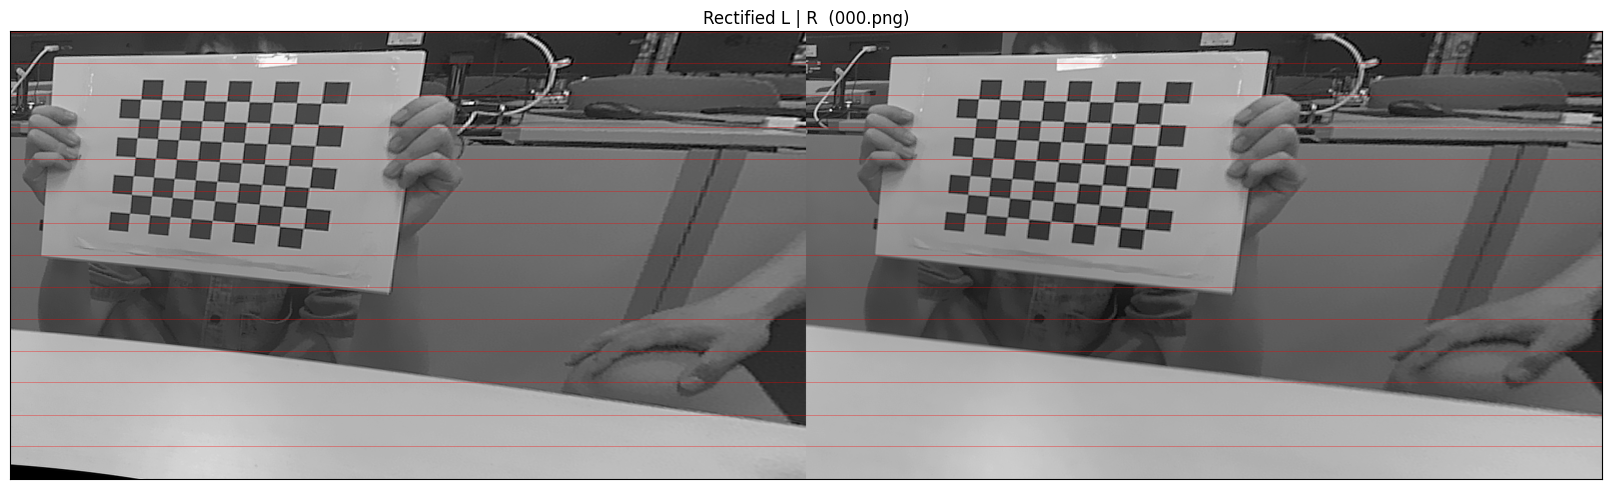

  non-zero pixels  L=918729/921600  R=921346/921600
L: 001.png  R: 001.png


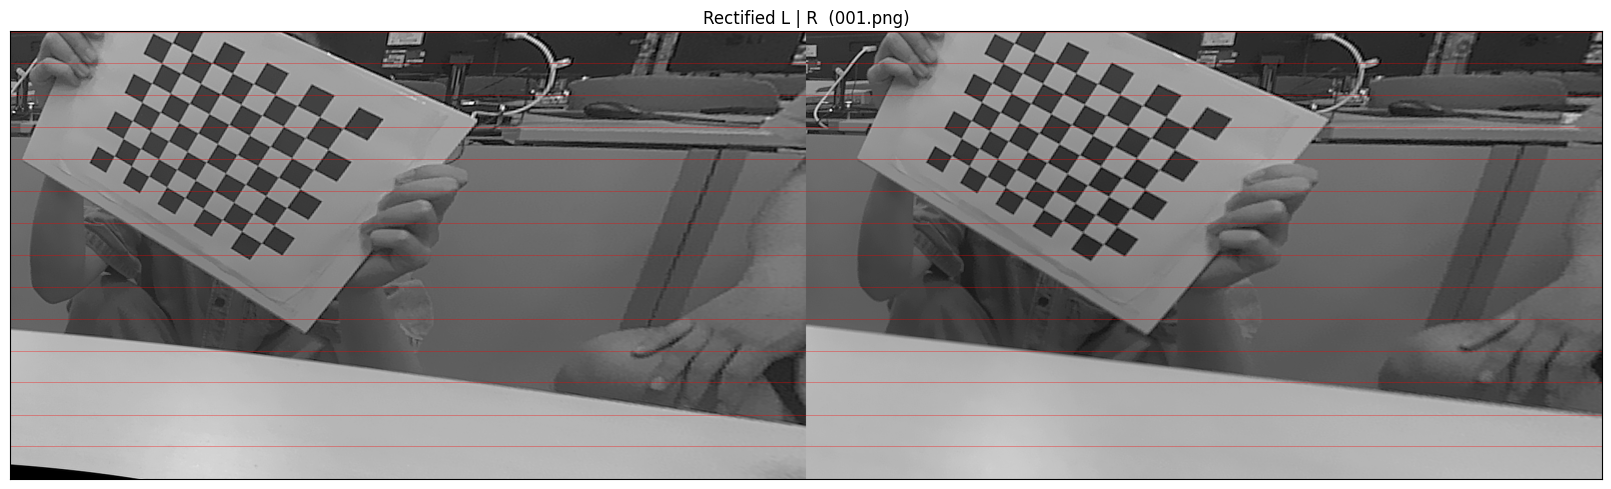

  non-zero pixels  L=918741/921600  R=921366/921600
L: 002.png  R: 002.png


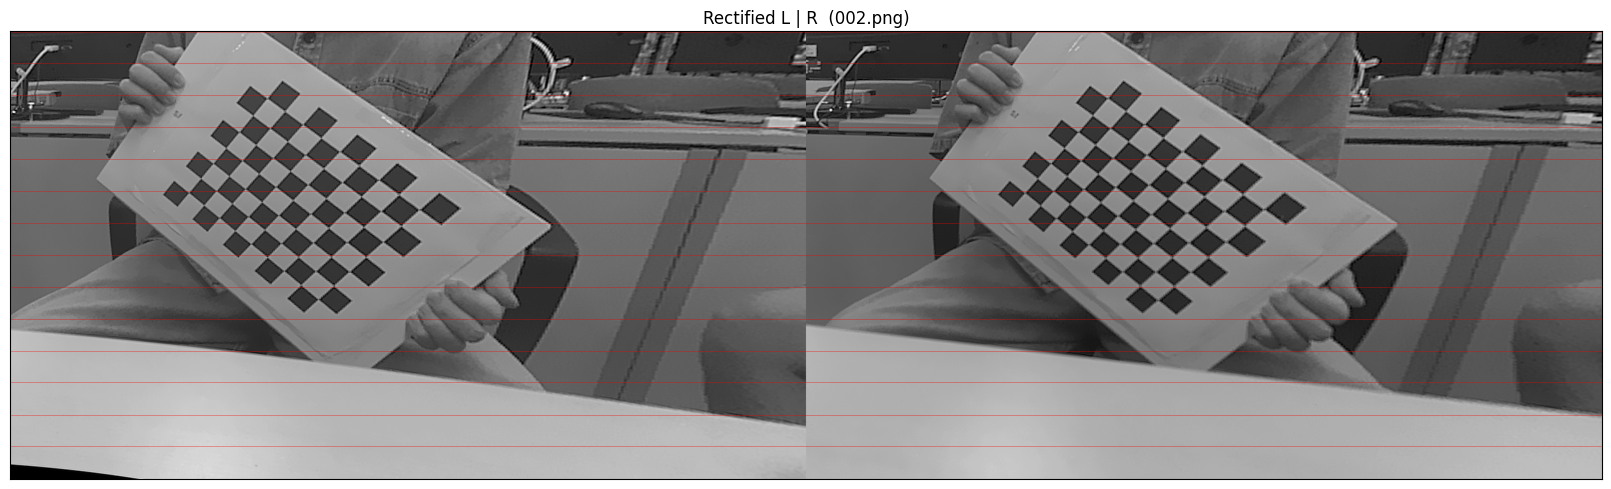

  non-zero pixels  L=918871/921600  R=921311/921600


In [12]:
# Sanity-check rectification. Shows full rectified frames side-by-side
# with horizontal epipolar guide lines spanning both. Correct rectification
# = a given world point lands on the same row in L and R.
N_PREVIEW = 3

pairs = list(zip(sorted(os.listdir(folder_left)), sorted(os.listdir(folder_right))))
for fname_l, fname_r in pairs[:N_PREVIEW]:
    print(f"L: {fname_l}  R: {fname_r}")
    arr_l = np.array(Image.open(folder_left + fname_l))
    arr_r = np.array(Image.open(folder_right + fname_r))
    if arr_l.ndim == 3:
        arr_l = cv2.cvtColor(arr_l, cv2.COLOR_BGR2GRAY)
        arr_r = cv2.cvtColor(arr_r, cv2.COLOR_BGR2GRAY)

    rect_l = cv2.remap(arr_l, left_stereo_maps[0], left_stereo_maps[1],
                       cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
    rect_r = cv2.remap(arr_r, right_stereo_maps[0], right_stereo_maps[1],
                       cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

    side = np.hstack([rect_l, rect_r])
    fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True)
    ax.imshow(side, cmap="gray")
    H = side.shape[0]
    for y in np.linspace(0, H - 1, 15, dtype=int):
        ax.axhline(y, color="r", lw=0.4, alpha=0.6)
    ax.set_title(f"Rectified L | R  ({fname_l})")
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

    nz_l = int((rect_l > 0).sum())
    nz_r = int((rect_r > 0).sum())
    print(f"  non-zero pixels  L={nz_l}/{rect_l.size}  R={nz_r}/{rect_r.size}")


### Save undistort+recity map

In [13]:
cv_file = cv2.FileStorage("rectify_map_imx219_160deg_720p.yaml", cv2.FILE_STORAGE_WRITE)
cv_file.write("map_l_x", left_stereo_maps[0])
cv_file.write("map_l_y", left_stereo_maps[1])
cv_file.write("map_r_x", right_stereo_maps[0])
cv_file.write("map_r_y", right_stereo_maps[1])
cv_file.release() 

### Export to rover_stereo schema (`stereo_calib.yaml`)

Writes K1/D1/K2/D2/R/T/image_size in PyYAML format consumed by 
`ros2_ws/src/rover_stereo/rover_stereo/rectify.py`. This file 
is **FROZEN** once committed — do not regenerate.

In [14]:
# rover_stereo schema export — run AFTER the stereoCalibrate cells above.
# Requires in-memory: K_l, dist_l, K_r, dist_r, Rot, Trns, retS, gray_l
import yaml, numpy as np
from pathlib import Path

W, H = gray_l.shape[::-1]
out = {
    "image_size": [int(W), int(H)],
    "K1": np.asarray(K_l, dtype=float).tolist(),
    "D1": np.asarray(dist_l, dtype=float).ravel().tolist(),
    "K2": np.asarray(K_r, dtype=float).tolist(),
    "D2": np.asarray(dist_r, dtype=float).ravel().tolist(),
    "R":  np.asarray(Rot, dtype=float).tolist(),
    "T":  np.asarray(Trns, dtype=float).ravel().tolist(),
    "reprojection_error_px": float(retS),
    "frozen": True,
    "note": "Captured by team/calibration/; pair 28 dropped. Do not regenerate.",
}
dst = Path.home() / "team/main/ros2_ws/src/rover_stereo/config/stereo_calib.yaml"
dst.write_text(yaml.safe_dump(out, sort_keys=False))
print(f"wrote {dst}  (RMS={retS:.4f}, |T|={np.linalg.norm(Trns):.2f} mm)")


wrote /home/ircv16/team/main/ros2_ws/src/rover_stereo/config/stereo_calib.yaml  (RMS=1.8399, |T|=41.42 mm)
